In [7]:
pip install pmdarima

  Using cached urllib3-2.5.0-py3-none-any.whl.metadata (6.5 kB)
   ---------------------------------------- 0.0/722.6 kB ? eta -:--:--
   - -------------------------------------- 30.7/722.6 kB 1.3 MB/s eta 0:00:01
   - -------------------------------------- 30.7/722.6 kB 1.3 MB/s eta 0:00:01
   - -------------------------------------- 30.7/722.6 kB 1.3 MB/s eta 0:00:01
   --- ----------------------------------- 61.4/722.6 kB 409.6 kB/s eta 0:00:02
   --- ----------------------------------- 61.4/722.6 kB 409.6 kB/s eta 0:00:02
   -------- ----------------------------- 153.6/722.6 kB 573.4 kB/s eta 0:00:01
   --------- ---------------------------- 184.3/722.6 kB 557.9 kB/s eta 0:00:01
   ---------- --------------------------- 194.6/722.6 kB 562.0 kB/s eta 0:00:01
   ---------- --------------------------- 194.6/722.6 kB 562.0 kB/s eta 0:00:01
   ---------- --------------------------- 194.6/722.6 kB 562.0 kB/s eta 0:00:01
   ---------- --------------------------- 194.6/722.6 kB 562.0 kB/s 


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
%reload_ext autoreload
%autoreload 2

# Forecasting Module Demo
Пример использования Forecaster c dummy-моделями.

In [3]:
import pandas as pd
import numpy as np
from multi_item_forecaster import MultiItemForecaster
from utils.plot import plot_forecast

shop_sales = pd.read_csv(r"C:\Users\makanov.artem\Desktop\ВР\data\shop_sales_store1.csv", index_col=0)
shop_dates = pd.read_csv(r"C:\Users\makanov.artem\Desktop\ВР\data\shop_sales_dates_store1.csv", index_col=0)

df = shop_sales.merge(shop_dates, on="date_id", how="left")
df = df[['item_id', 'date', 'cnt']]

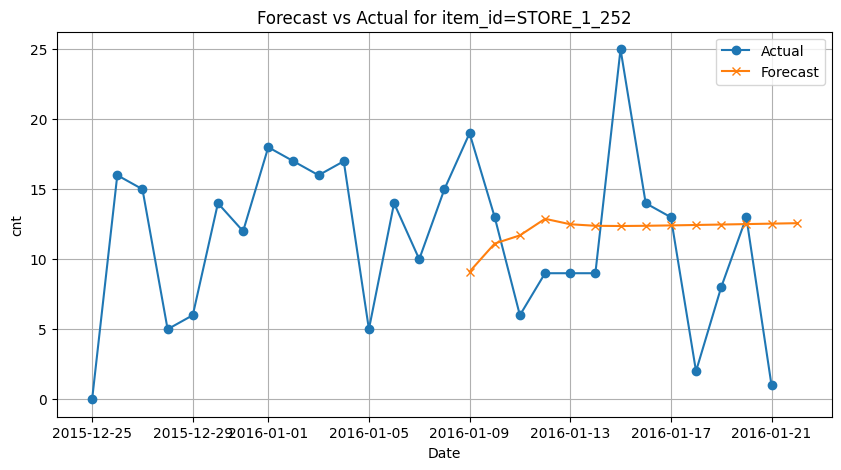

{'SMAPE': np.float64(66.9612606723448),
 'WAPE': np.float64(inf),
 'RMSE': np.float64(9.30424666985704),
 'MASE': np.float64(1.3159112839038407)}

In [16]:
horizon = 14
last_k_days = 28

multi_fc = MultiItemForecaster(model_name="arima")
multi_fc.fit(df, order=(2,0,1), seasonal_order=(0,0,1,4))

forecasts = multi_fc.predict(horizon=horizon)

plot_forecast(df, forecasts, item_id='STORE_1_252', horizon=horizon, last_k_days=last_k_days)

metrics_per_item, metrics_agg = multi_fc.evaluate(df, horizon=horizon)
metrics_agg

In [48]:
df.item_id.unique()

array(['STORE_1_046', 'STORE_1_033', 'STORE_1_043', 'STORE_1_090',
       'STORE_1_099', 'STORE_1_131', 'STORE_1_252', 'STORE_1_295',
       'STORE_1_304', 'STORE_1_491', 'STORE_1_542', 'STORE_1_555',
       'STORE_1_586', 'STORE_1_587', 'STORE_1_714'], dtype=object)

In [50]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df[df.item_id == 'STORE_1_542'].cnt)
print('ADF p-value:', result[1])

ADF p-value: 1.9431540287504534e-06


In [5]:
series = df[df.item_id == 'STORE_1_542'].cnt

In [15]:
import pmdarima as pm

model = pm.auto_arima(
    series,
    seasonal=True,
    m=4,               # сезонный период (например 7 дней)
    stepwise=True,
    trace=True,
    error_action='ignore'
)

print(model.summary())


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[4] intercept   : AIC=5554.562, Time=4.42 sec
 ARIMA(0,0,0)(0,0,0)[4] intercept   : AIC=5702.852, Time=0.04 sec
 ARIMA(1,0,0)(1,0,0)[4] intercept   : AIC=5602.817, Time=0.50 sec
 ARIMA(0,0,1)(0,0,1)[4] intercept   : AIC=5614.142, Time=0.52 sec
 ARIMA(0,0,0)(0,0,0)[4]             : AIC=6286.280, Time=0.03 sec
 ARIMA(2,0,2)(0,0,1)[4] intercept   : AIC=5540.507, Time=3.15 sec
 ARIMA(2,0,2)(0,0,0)[4] intercept   : AIC=5550.734, Time=0.85 sec
 ARIMA(2,0,2)(0,0,2)[4] intercept   : AIC=5552.006, Time=2.00 sec
 ARIMA(2,0,2)(1,0,0)[4] intercept   : AIC=5550.038, Time=1.12 sec
 ARIMA(2,0,2)(1,0,2)[4] intercept   : AIC=5554.480, Time=4.26 sec
 ARIMA(1,0,2)(0,0,1)[4] intercept   : AIC=5537.886, Time=2.70 sec
 ARIMA(1,0,2)(0,0,0)[4] intercept   : AIC=5538.250, Time=1.54 sec
 ARIMA(1,0,2)(1,0,1)[4] intercept   : AIC=5546.547, Time=3.02 sec
 ARIMA(1,0,2)(0,0,2)[4] intercept   : AIC=5539.862, Time=3.56 sec
 ARIMA(1,0,2)(1,0,0)[4] intercept